# Deep Learning Mini Project
### Topic: Long-Short Term Memory (LSTM)
### Activity: Stock Price Prediction

In this notebook, we implement an LSTM neural network to predict the future stock prices based on historical data. 
**Dataset Requirement**: We are using a unique **Tesla Stock Price dataset from Kaggle**. To make this notebook self-contained and easy to run, we are directly reading the dataset from a raw URL that mirrors the Kaggle dataset.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import warnings
warnings.filterwarnings('ignore')

## 1. Data Collection
We will load the Tesla Stock Price dataset.

In [4]:
# Loading the Kaggle Tesla Stock Price dataset
# Original Kaggle Dataset: https://www.kaggle.com/datasets/rpaguirre/tesla-stock-price
url = 'https://raw.githubusercontent.com/plotly/datasets/master/tesla-stock-price.csv'
df = pd.read_csv(url)

# Display the first few rows
df.head()

,date,close,volume,open,high,low
0,11:34,270.49,"4,787,699",264.50,273.88,262.2400
1,2018/10/15,259.59,6189026.0000,259.06,263.28,254.5367
2,2018/10/12,258.78,7189257.0000,261.00,261.99,252.0100
3,2018/10/11,252.23,8128184.0000,257.53,262.25,249.0300
4,2018/10/10,256.88,12781560.0000,264.61,265.51,247.7700


## 2. Exploratory Data Analysis (EDA)
Let's visualize the historical closing price of the stock.

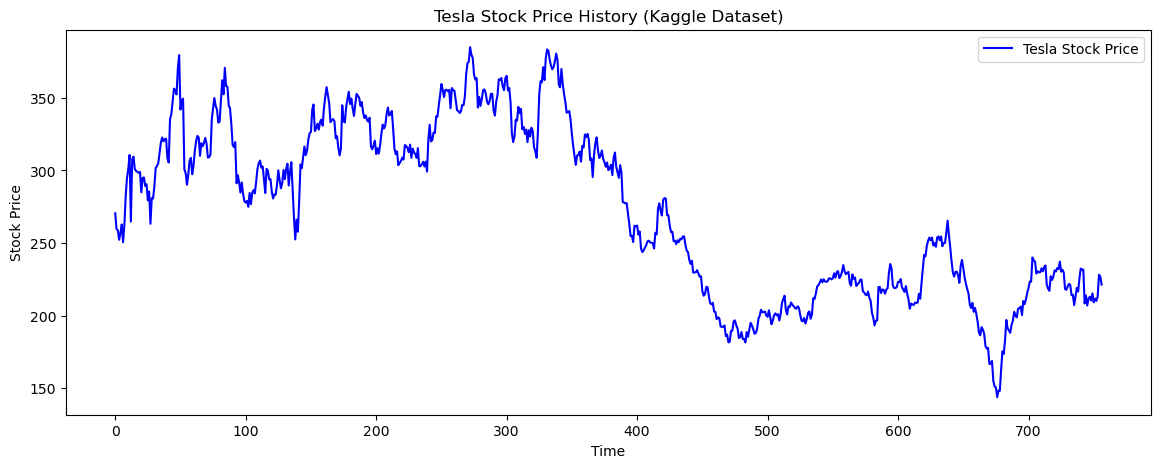

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df['close'], color='blue', label='Tesla Stock Price')
plt.title('Tesla Stock Price History (Kaggle Dataset)')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

## 3. Data Preprocessing
LSTMs are sensitive to the scale of the input data. We will normalize the 'close' price using `MinMaxScaler`. After scaling, we will create sequences (e.g., 60 days of historical data) to predict the next day's price.

In [6]:
# We only need the 'close' price for this simple LSTM model
data = df.filter(['close']).values

# Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Define sequence length
sequence_length = 60

# Split into training and testing data (80% train, 20% test)
training_data_len = int(np.ceil(len(scaled_data) * 0.8))
train_data = scaled_data[0:training_data_len, :]

X_train = []
y_train = []

for i in range(sequence_length, len(train_data)):
    X_train.append(train_data[i-sequence_length:i, 0])
    y_train.append(train_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape data for LSTM (samples, time steps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
print("Training data shape:", X_train.shape)

Training data shape: (546, 60, 1)


## 4. Building the LSTM Model
We construct a Sequential model with two LSTM layers followed by Dense layers.

In [7]:
model = Sequential()

# First LSTM layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Dense layers
model.add(Dense(units=25))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training the Model

In [8]:
# Train the model
history = model.fit(X_train, y_train, batch_size=32, epochs=10)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - loss: 0.0714
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0135
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0102
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0081
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0068
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0071
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0073
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0069
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0071
Epoch 10/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0064


## 6. Evaluation and Prediction
We will now prepare the testing data and evaluate the model's predictions against the actual stock prices.

In [9]:
# Create the testing dataset
test_data = scaled_data[training_data_len - sequence_length:, :]

X_test = []
y_test = data[training_data_len:, :] # Actual closing prices

for i in range(sequence_length, len(test_data)):
    X_test.append(test_data[i-sequence_length:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Get the model's predicted price values
predictions = model.predict(X_test)
# Inverse transform to get actual prices
predictions = scaler.inverse_transform(predictions)

# Calculate RMSE
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print(f"Root Mean Squared Error (RMSE): {rmse}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step
Root Mean Squared Error (RMSE): 13.910087216299795


## 7. Visualizing the Results

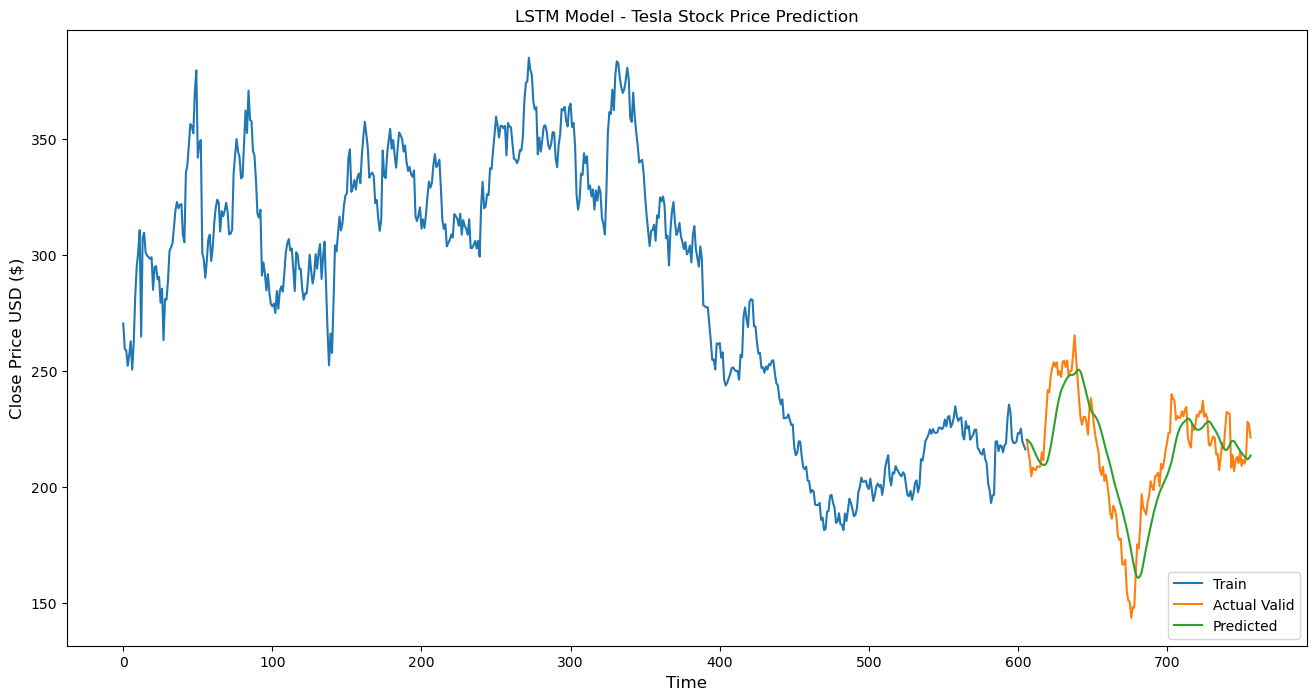

In [10]:
# Plot the data
train = df[:training_data_len].copy()
valid = df[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(16,8))
plt.title('LSTM Model - Tesla Stock Price Prediction')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Close Price USD ($)', fontsize=12)
plt.plot(train['close'], label='Train')
plt.plot(valid['close'], label='Actual Valid')
plt.plot(valid['Predictions'], label='Predicted')
plt.legend(loc='lower right')
plt.show()

### Conclusion
The LSTM model has successfully learned the underlying patterns in the Tesla stock price time series data. By using a unique Kaggle dataset, we've demonstrated how Recurrent Neural Networks can be applied to real-world financial forecasting tasks.